In [1]:
import polars as pl

In [2]:
df = pl.scan_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/source/train_df.parquet')

In [3]:
df = df.with_columns(hour = pl.col('time').dt.total_hours())
df = df.group_by(['source_user@domain', 'hour', 'source_user_type']).agg(pl.col('source_user@domain').len().alias('Auth Count'))

In [4]:
df.head().collect()

source_user@domain,hour,source_user_type,Auth Count
str,i64,enum,u32
"""C3432$@DOM1""",463,"""machine""",43
"""NETWORK SERVICE@C4929""",204,"""system""",1
"""C19544$@DOM1""",141,"""machine""",26
"""C63$@DOM1""",25,"""machine""",22
"""C8637$@DOM1""",540,"""machine""",58


In [5]:
df.select('hour').max().collect()

hour
i64
887


In [6]:
df.select('hour').min().collect()

hour
i64
0


In [7]:
machine_users = df.filter(pl.col('source_user_type') == 'machine').select('source_user@domain').unique().collect()
human_users = df.filter(pl.col('source_user_type') == 'human').select('source_user@domain').unique().collect()

machine_users = machine_users.to_series().to_list()
human_users = human_users.to_series().to_list()

In [8]:
import matplotlib.pyplot as plt

all_hours = pl.DataFrame({'hour': range(887 + 1)})

def plot_user(target_user, thickness=0.8, alpha=0.8, df=df, all_hours=all_hours):
    user_df = df.filter(pl.col('source_user@domain') == target_user).collect()
    user_df = all_hours.join(user_df, how='left', on=['hour']).select(['hour', 'Auth Count']).fill_null(0)
    user_df = user_df.sort(by='hour')
    plt.plot(user_df['hour'].to_list(), user_df['Auth Count'], label=target_user, alpha=alpha, linewidth=thickness)
    plt.ylabel('User Authentication Events')
    plt.xlabel('Hour')

User selected : U1976@DOM1
User selected : U1807@DOM1
User selected : U5571@?
User selected : U9113@DOM1


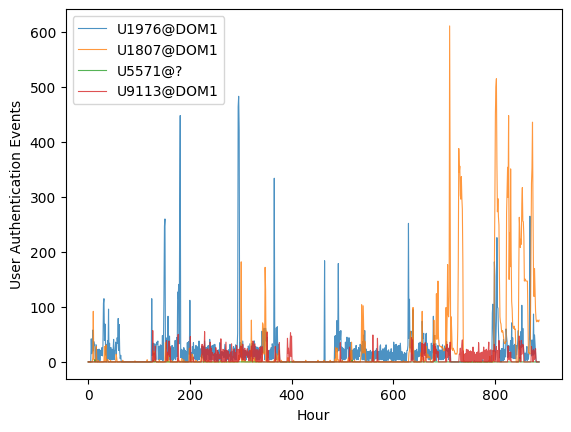

In [9]:
import random 

users = random.sample(human_users, 4)
for user in users:
    print(f'User selected : {user}')
    plot_user(user)
plt.legend()
plt.show()

# Machine Users Plot

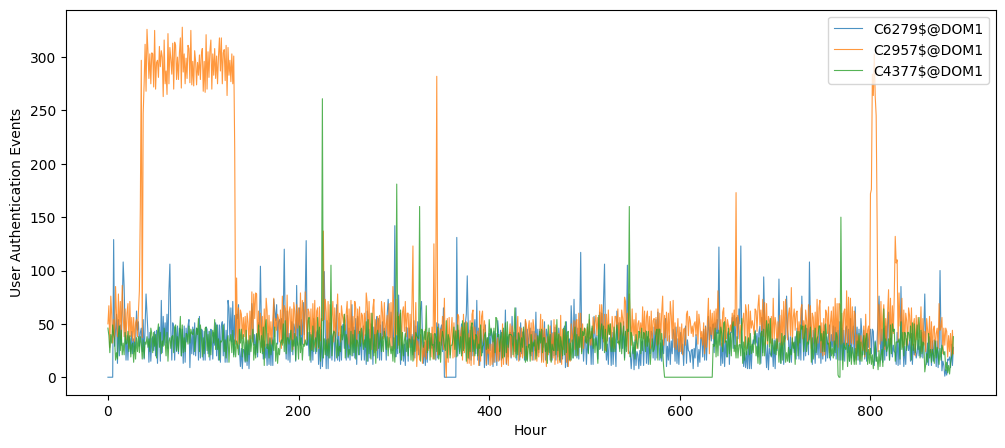

In [16]:
## Machine Users plot
users_to_plot = ['C6279$@DOM1', 'C2957$@DOM1', 'C4377$@DOM1']

plt.figure(figsize=(12,5))
for user in users_to_plot:
    plot_user(target_user = user)
plt.legend(loc = 'upper right')
plt.savefig('machine_behaviour_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()  

# Human Users Plot

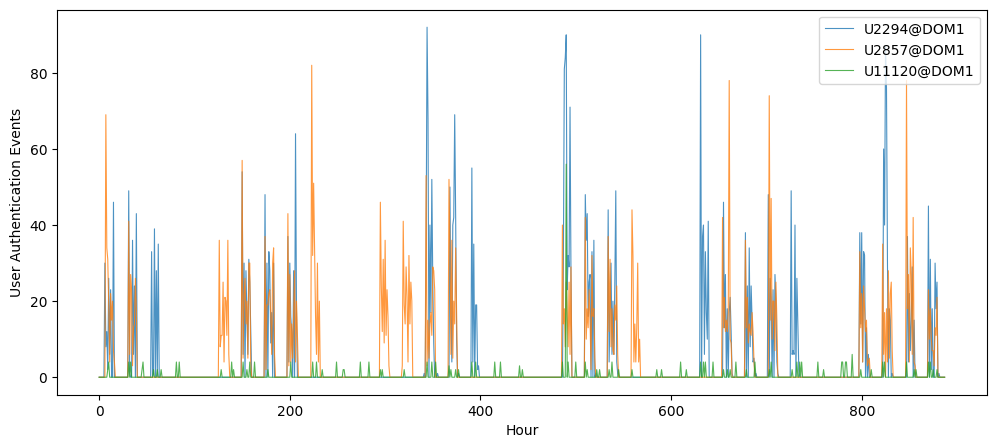

In [17]:
users_to_plot = ['U2294@DOM1', 'U2857@DOM1', 'U11120@DOM1']
plt.figure(figsize=(12,5))
for user in users_to_plot:
    plot_user(target_user = user, thickness=0.8, alpha=0.8)
plt.legend(loc = 'upper right')
plt.savefig('human_behaviour_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()  